Code not used for anything in the text; written to check if RSFM can capture the unjamming dynamics

# FSM

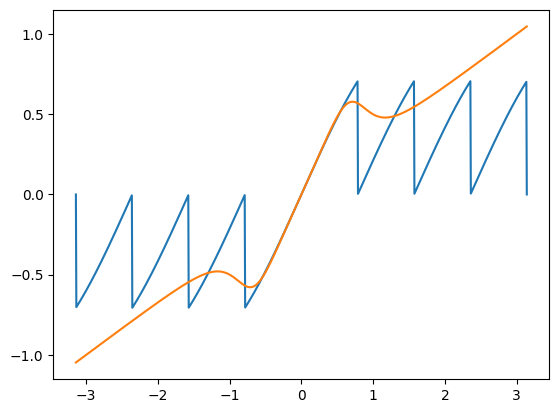

In [304]:
delta_theta=np.linspace(-np.pi,np.pi,1000)
k=(np.pi/4)*np.sign(delta_theta)*(np.abs(delta_theta)//(pi/4))
dphi_dt=-(np.cos(delta_theta)*(np.sin(k)-np.sin(delta_theta))-np.sin(delta_theta)*(np.cos(k)-np.cos(delta_theta)))
dphi_dt2=delta_theta/(2*delta_theta**6/(1+delta_theta**6)+1)
plt.plot(delta_theta,dphi_dt)
plt.plot(delta_theta,dphi_dt2)

In [127]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from matplotlib.animation import FuncAnimation
import matplotlib.patches as patches
from math import cos, sin, pi
from IPython.display import HTML, Video, display

"""
-----------------------
Helper Functions: Later move it to another file.py
-----------------------

"""
def selfPropulsionForce_rot(m, tau, desiredSpeed, desiredDirection, velocity,tphi):
    desiredDirection=np.arctan2(desiredDirection[:,1],desiredDirection[:,0])

    speed=((velocity**2).sum(axis=1))**0.5
    angle=np.arctan2(velocity[:,1],velocity[:,0])
    desiredSpeed=desiredSpeed.ravel()
    ds_dt=(desiredSpeed-speed)*(m/tau)
    delta_theta=np.arctan2(np.sin(desiredDirection-angle),np.cos(desiredDirection-angle))
    # dphi_dt=delta_theta/(6*np.exp(delta_theta**2)/(1+np.exp(delta_theta**2)-2.5))
    dphi_dt=delta_theta/(2*delta_theta**6/(1+delta_theta**6)+0.5)
    # dphi_dt=np.sin(delta_theta)
    # k=(np.pi/8)*np.sign(delta_theta)*(np.abs(delta_theta)//(pi/8))
    # dphi_dt=-(np.cos(delta_theta)*(np.sin(k)-np.sin(delta_theta))-np.sin(delta_theta)*(np.cos(k)-np.cos(delta_theta)))
    # dphi_dt=np.sign(delta_theta)*(1/tphi)*np.abs(delta_theta)>0.01
    # dphi_dt=np.sign(delta_theta)*2
    # dphi_dt=np.arctan2(np.sin(desiredDirection-angle),np.cos(desiredDirection-angle))*(m/tphi)
    outforce=np.zeros_like(velocity)
    outforce[:,0]=ds_dt*np.cos(angle)+dphi_dt*(-speed*np.sin(angle))
    outforce[:,1]=ds_dt*np.sin(angle)+dphi_dt*(speed*np.cos(angle))
    return outforce

def selfPropulsionForce_og(m, tau, desiredSpeed, desiredDirection, velocity,tphi):
    desiredVelocity = desiredSpeed * desiredDirection
    return (desiredVelocity - velocity) * (m / tau)

def interactionForce(position, R, A, B, Lx, Ly):
    N = position.shape[0]
    epsilon = 1e-6 # Used to avoid infinity
    agent_size = 2 * R

    x = position[:, 0].reshape(-1, 1)
    y = position[:, 1].reshape(-1, 1)

    dx = x - x.T
    dy = y - y.T


    dx_u = dx - np.round(dx / Lx) * Lx
    dy_u = dy - np.round(dy / Ly) * Ly

    # Euclidean distance calculation
    dist = np.sqrt(dx_u**2 + dy_u**2)
    
    valid_index = (dist < (3*R)) & (dist > 0)

    # Unit vectors
    dij_x = np.zeros_like(dist)
    dij_y = np.zeros_like(dist)
    np.divide(dx_u, dist, out=dij_x, where=dist>epsilon)
    np.divide(dy_u, dist, out=dij_y, where=dist>epsilon)   
    # np.divide(dx_u, dist+epsilon, out=dij_x)#, where=dist>epsilon)
    # np.divide(dy_u, dist+epsilon, out=dij_y)#, where=dist>epsilon)
    
    # Apply valid_index mask
    dij_x[~valid_index] = 0
    dij_y[~valid_index] = 0
    
    # Effective distance
    effective_dist = np.maximum(dist - agent_size, epsilon)
    
    # Force magnitude calculation
    force_magnitude = np.zeros_like(dist)
    np.power(effective_dist, -B, out=force_magnitude, where=effective_dist>epsilon)
    force_magnitude *= -A
    
    force_magnitude[~valid_index] = 0

    interaction_force = np.column_stack((np.sum(force_magnitude * dij_x, axis=0),np.sum(force_magnitude * dij_y, axis=0)))

    return interaction_force


In [128]:
# Imports and Initializations
import numpy as np
import matplotlib.pyplot as plt

from parfor import parfor
import csv
from tqdm import tqdm

In [129]:
# Setting model parameters


def periodify(pos,Lx,Ly):
    if len(pos.shape)==1:
        pos[0]=pos[0]%Lx
        pos[1]=pos[1]%Ly
    else:
        pos[:,0]=pos[:,0]%Lx
        pos[:,1]=pos[:,1]%Ly
    return pos



def getdisp(a,b):
    disp=a-b
    if len(disp.shape)==1:
        disp[0]=disp[0]-np.round(disp[0]/Lx)*Lx
        disp[1]=disp[1]-np.round(disp[1]/Ly)*Ly
    else:
        disp[:,0]=disp[:,0]-np.round(disp[:,0]/Lx)*Lx
        disp[:,1]=disp[:,1]-np.round(disp[:,1]/Ly)*Ly
    return disp





# Parallel

In [130]:
from tqdm import tqdm
import pickle


deltaT = 0.005
timeStep = 35000#+15000
totalTime = deltaT*timeStep




N=40
Lx=80
Ly=19
R = 1
m = 1
A = 0.01
B = 3
tau = 1


updateT=tau
updateF=round(updateT/deltaT)



Nr = 1/2
deltheta=np.pi/8
numagents=N
tau_fut=6
agentradius=R

numsamp=50





# number of agent in each group
g1 = int(round(N * Nr))
# g1=1
g2 = N - g1


In [158]:
# Initial Position
tphi=0.01
rep=1
for columns in [8]:
    xData = []
    yData = []
    uData = []
    vData = []
    desdirs=[]
    forces=[]


    N=columns*10
    Lx=columns*5
    numagents=N
    g1 = int(round(N * Nr))
    g2 = N - g1
    
    
    # position=np.array(sum([[[x,y] for y in [1.9,5.7,9.5,13.3,17.1]] for x in [2,4.5,7,9.5,12,14.5,17,19.5]],[]))#[np.random.permutation(np.arange(N))]
    # position=np.array(sum([[[x,y] for y in [1.5,5.5,9.5,13.5,17.5]] for x in [2,4.5,7,9.5,12,14.5,17,19.5]],[]))#[np.random.permutation(np.arange(N))]

    position=np.array(sum([[[x,y] for y in [1.5,5.5,9.5,13.5,17.5]] for x in np.arange(2,Lx,2.5)],[]))#[np.random.permutation(np.arange(N))]
    # position[g1:,0]=position[g1:,0]+5
    # Lx+=5
    
    # position=np.array(sum([[[x,y] for y in [1.25,3.75,6.25,8.75,11.25,13.75,16.25,18.75]] for x in [2,4.5,7,9.5,12,14.5,17,19.5]],[]))#[np.random.permutation(np.arange(N))]
    # position=np.array([[4,4],[17,4]])
    # position=np.array([[4.5,9.5]]+sum([[[x,y] for y in [1.5,5.5,9.5,13.5,17.5]] for x in [12,14.5,17,19.5]],[]))
    # position=np.array([[3,10]]+list(np.random.random(size=(5,2))*18)+[[17,10]])
    # position=startpos.copy()[np.random.permutation(np.arange(90))]
    # position=position+(np.random.random(size=position.shape)-0.5)*0.001
    position[:g1,1]=position[:g1,1]+0.001
    position[:,0]=position[:,0]%Lx
    position[:,1]=position[:,1]%Ly
    
    # Initial Speed
    # speed = np.array([1,1]).reshape(-1,1)
    speed=0
    
    # Initial Direction
    theta = np.random.uniform(0, 2* np.pi, size = (N, 1))
    # theta=np.array([0,np.pi/2]).reshape(-1,1)
    # theta = np.ones(shape=(N,1))*np.pi/2
    # print(theta)
    # Parameter for force calculation
    
    
    # Inital velocity
    velocity = speed * np.column_stack((np.cos(theta), np.sin(theta)))
    
    # Desired speed
    desiredSpeed = np.ones((N,1)) * 1
    # desiredSpeed[:g1] = 0
    
    
    # Desired direction
    desiredDirectionA = np.ones((N, 1))
    desiredDirectionA[:g1] = 0
    desiredDirectionA[g1:] = np.pi
    desired=(desiredDirectionA.copy()).ravel()
    desiredDirection = np.hstack((np.cos(desiredDirectionA), np.sin(desiredDirectionA)))


    # ############################################################

    # file=glob('./40agents_nofsm/*_11_*.pickle')[0]
    # with open(file,'rb') as f:
    #     alldat=pickle.load(f)
    #     position=np.vstack([alldat['xData'][0],alldat['yData'][0]]).T
    #     velocity=np.vstack([alldat['uData'][0],alldat['vData'][0]]).T

    # ############################################################
    
    xData.append(position[:,0])
    yData.append(position[:,1])
    
    uData.append(velocity[:,0])
    vData.append(velocity[:,1])
    
    
    
    
    
    for t in tqdm(range(timeStep)):
        if t*deltaT<35:
            selfPropulsionForce=selfPropulsionForce_og
        else:
            selfPropulsionForce=selfPropulsionForce_rot
        desdirs.append(desiredDirection[:].copy())
      # Force calculation
        f1 = selfPropulsionForce(m, tau, desiredSpeed, desiredDirection, velocity,tphi)#*np.random.normal(0,1,size=(N,2))
        f2 = interactionForce(position, R, A, B, Lx,Ly)
        force = (f1+f2)/m

        newPosition = position + (velocity * deltaT) + (0.5 * force * deltaT**2)
        newPosition[:,0] = (newPosition[:,0]) % Lx
        newPosition[:,1] = (newPosition[:,1]) % Ly
    

        deltaV = force * deltaT
    
        vint = velocity + deltaV
    
        f1_new = selfPropulsionForce(m, tau, desiredSpeed, desiredDirection, vint,tphi) 
        f2_new =  interactionForce(newPosition, R, A, B, Lx,Ly)
        
        forceNew = (f1_new + f2_new)/m
        
        newVelocity = velocity + (0.5 * (force + forceNew)) * deltaT
    
        velocity = newVelocity
        position = newPosition
        

        xData.append(newPosition[:,0])
        yData.append(newPosition[:,1])
        
        uData.append(newVelocity[:,0])
        vData.append(newVelocity[:,1])
        forces.append([f1,f2])

    # with open('./40agents_nematic_jamresolve/'+str(N)+'_agents_nofsm_nematic_'+str(tphi)+'tauphi_random_start_'+str(rep)+'_'+str(np.random.randint(10000))+'.pickle','wb') as file:
    #     pickle.dump({'xData':xData,'yData':yData,'uData':uData,'vData':vData,'forces':forces,'desdirs':desdirs,'tphi':tphi,'g1':g1},file)#,'note':'tried to incorporate neighbor effects while predicting motion of other agents'},file)


    


100%|███████████████████████████████████████████████████████████████████████████| 35000/35000 [01:03<00:00, 554.55it/s]


In [6]:
# import pickle
# with open('sdfsaDFaf_40_agents_withfsm','wb') as file:
#     pickle.dump({'xData':xData,'yData':yData,'uData':uData,'vData':vData,'forces':forces,'desdirs':desdirs},file)#,'note':'tried to incorporate neighbor effects while predicting motion of other agents'},file)

# alldata={'xData':xData,'yData':yData,'uData':uData,'vData':vData,'forces':forces,'desdirs':desdirs,'note':'tried to incorporate neighbor effects while predicting motion of other agents'}

# plots

In [157]:
# Ploting velocity data
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype']='none'
from glob import glob
filestart='./sadf_40agents_nofsm_nematic_halftauphi_random_start/*.pickle'
files=glob(filestart)
uData_all=[]
for file in files:
    with open(file,'rb') as f:
        uData_all.append(pickle.load(f)['uData'])

uData_all=np.array(uData_all)

uData_p_mean = np.array(uData_all).reshape(15,35001,40).mean(axis=0)
uData_p_median = np.quantile(np.array(uData_all).reshape(15,35001,40),0.5,axis=0)
uData_p_lq = np.quantile(np.array(uData_all).reshape(15,35001,40),0.25,axis=0)
uData_p_uq = np.quantile(np.array(uData_all).reshape(15,35001,40),0.75,axis=0)
uData_p_min = np.quantile(np.array(uData_all).reshape(15,35001,40),0.1,axis=0)
uData_p_max = np.quantile(np.array(uData_all).reshape(15,35001,40),0.9,axis=0)


# print(uData_p.shape)
for rep in range(1):
    # order_g1 = np.mean(uData_p[rep*35001:(rep+1)*35001, :g1], axis = 1)
    # order_g2 = np.mean(uData_p[rep*35001:(rep+1)*35001, g1:], axis = 1)
    t = np.arange(0, totalTime, deltaT)
    t=np.arange(35001)*deltaT
    
    plt.figure()
    plt.plot(t,uData_p_median[:,:g1].mean(axis=1), label = 'Group 1 [right]',color='red')
    plt.fill_between(t,uData_p_lq[:,:g1].mean(axis=1),uData_p_uq[:,:g1].mean(axis=1),alpha=0.6,color='red')
    plt.fill_between(t,uData_p_min[:,:g1].mean(axis=1),uData_p_max[:,:g1].mean(axis=1),alpha=0.1,color='red')
    plt.plot(t,uData_p_median[:,g1:].mean(axis=1), label = 'Group 2 [left]',color='blue')
    plt.fill_between(t,uData_p_lq[:,g1:].mean(axis=1),uData_p_uq[:,g1:].mean(axis=1),alpha=0.6,color='blue')
    plt.fill_between(t,uData_p_min[:,g1:].mean(axis=1),uData_p_max[:,g1:].mean(axis=1),alpha=0.1,color='blue')
    plt.ylim(-1.05,1.05)
    # plt.xlim([0, 10])
plt.title('Average x-component velocity without predictive control (polar restitution, $\\tau_{\\phi}=0.5$, random start)')
plt.xlabel('Time, s')
plt.ylabel(r'$v_{x}$')
plt.legend()
plt.savefig('./asdf_results_40agents/nofsm_nematic_halftauphi_random_start.svg',facecolor='white',bbox_inches='tight')
# plt.axvline(13)
# plt.legend()

ValueError: cannot reshape array of size 0 into shape (15,35001,40)

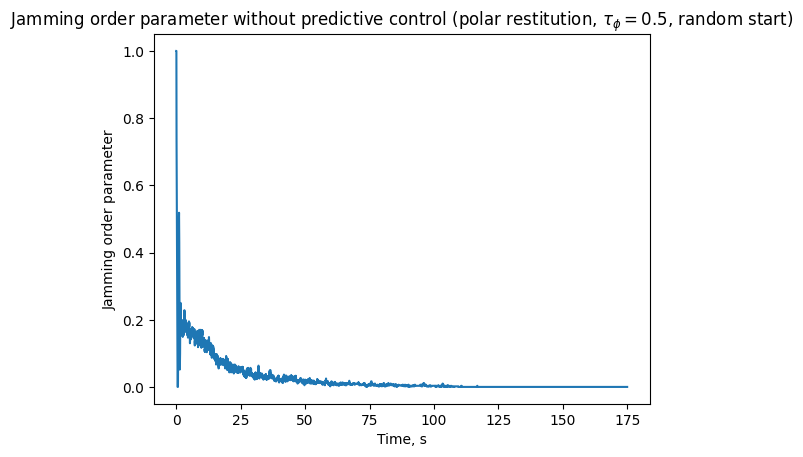

In [10]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype']='none'
g1=20
uvel_g1=np.array(uData_all).reshape(15,35001,40).T[:g1]
uvel_g1=uvel_g1.transpose(0,2,1)
uvel_g1=uvel_g1.reshape(-1, uvel_g1.shape[-1]).T

uvel_g2=np.array(uData_all).reshape(15,35001,40).T[g1:]
uvel_g2=uvel_g2.transpose(0,2,1)
uvel_g2=uvel_g2.reshape(-1, uvel_g2.shape[-1]).T

num_g1=(uvel_g1<0.15).sum(axis=1)
num_g2=(uvel_g2>-0.15).sum(axis=1)
jam_op=(num_g1+num_g2)/(40*15)
plt.plot(t,jam_op)

plt.xlabel('Time, s')
plt.ylabel('Jamming order parameter')
plt.title('Jamming order parameter without predictive control (polar restitution, $\\tau_{\\phi}=0.5$, random start)')
plt.savefig('./sdf_results_40agents/jam_op_nofsm_nematic_halftauphi_random_start.svg',facecolor='white',bbox_inches='tight')

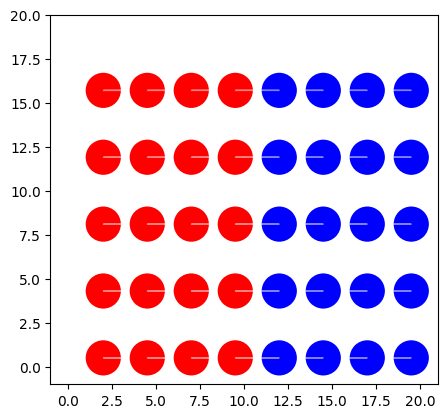

In [37]:
# xData=np.array(xData).T
# xData=np.array(xData).T
for i in range(1):
# for i in (14*200,14*200+1):
    plt.figure()
    for ag in range(N):
        xpos=(xData[i][ag])
        ypos=((yData[i][ag])+10)%19
        vx=uData[i][ag]
        vy=vData[i][ag]
        desx=desdirs[i][ag,0]
        desy=desdirs[i][ag,1]
        # dir=cmath.rect(1,dirdata[t,ag])
        plt.gca().add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue'))
        plt.arrow(xpos,ypos,vx,vy)
        plt.arrow(xpos,ypos,desx,desy,color='white',alpha=0.5)
        # plt.arrow(xpos,ypos,np.real(dir),np.imag(dir))
    plt.xlim(-1,Lx+1)
    plt.ylim(-1,Ly+1)
    plt.gca().set_aspect(1)

(35001, 80)


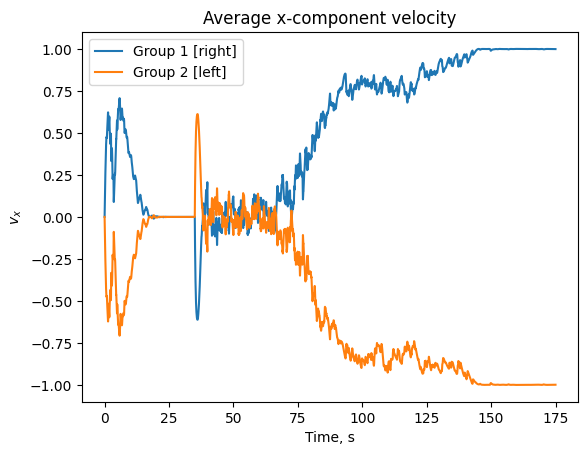

In [159]:

# import numpy as np
# import matplotlib.pyplot as plt
# plt.rcParams['svg.fonttype']='none'
# from glob import glob
# filestart='./40agents_nofsm/*.pickle'
# files=glob(filestart)
# for file in files:
#     with open(file,'rb') as f:
#         uData=pickle.load(f)['uData']
#     plt.figure()
#     print(file)
    
uData_p = np.array(uData)
# vData_p = np.array(vData)
print(uData_p.shape)
order_g1 = np.mean(uData_p[:, :g1], axis = 1)
order_g2 = np.mean(uData_p[:, g1:], axis = 1)
t = np.arange(0, totalTime, deltaT)


# plt.figure()
plt.plot(t, order_g1[:-1], label = 'Group 1 [right]')
plt.plot(t, order_g2[:-1], label = 'Group 2 [left]')
# plt.xlim([0, 10])
# plt.title(file)
plt.title('Average x-component velocity')
plt.xlabel('Time, s')
plt.ylabel(r'$v_{x}$')
# plt.xscale('log')
# plt.axvline(13)
plt.legend()

In [161]:
file=glob('./jam_length/80*.pickle')[0]
with open(file,'rb') as f:
    alldat=pickle.load(f)
    xData=alldat['xData']
    yData=alldat['yData']
    uData=alldat['uData']
    vData=alldat['vData']
    desdirs=alldat['desdirs']

In [162]:

filename='./images/ajamresolve_test'
for i in range(0,timeStep,125):
# for i in (14*200,14*200+1):
    plt.figure()
    for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]
        desx=desdirs[i][ag,0]
        desy=desdirs[i][ag,1]
        # dir=cmath.rect(1,dirdata[t,ag])
        plt.gca().add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue'))
        plt.arrow(xpos,ypos,vx,vy)
        plt.arrow(xpos,ypos,desx,desy,color='white',alpha=0.5)
        # plt.arrow(xpos,ypos,np.real(dir),np.imag(dir))
    plt.xlim(-1,Lx+1)
    plt.ylim(-1,Ly+1)
    # plt.axhline(0)
    # plt.axhline(Ly)
    plt.gca().set_aspect(1)
    plt.savefig(filename+'_prop_'+str(i)+'.png',facecolor='white')
    plt.close()

./40agents_withfsm_unjamming\40_agents_withfsm_unjamming_35s_0_8521.pickle
(35001, 40)
./40agents_withfsm_unjamming\40_agents_withfsm_unjamming_35s_10_5111.pickle
(35001, 40)
./40agents_withfsm_unjamming\40_agents_withfsm_unjamming_35s_11_4731.pickle
(35001, 40)
./40agents_withfsm_unjamming\40_agents_withfsm_unjamming_35s_12_6072.pickle
(35001, 40)
./40agents_withfsm_unjamming\40_agents_withfsm_unjamming_35s_13_6902.pickle
(35001, 40)
./40agents_withfsm_unjamming\40_agents_withfsm_unjamming_35s_14_1063.pickle
(35001, 40)
./40agents_withfsm_unjamming\40_agents_withfsm_unjamming_35s_1_4974.pickle
(35001, 40)
./40agents_withfsm_unjamming\40_agents_withfsm_unjamming_35s_2_4437.pickle
(35001, 40)
./40agents_withfsm_unjamming\40_agents_withfsm_unjamming_35s_3_2671.pickle
(35001, 40)
./40agents_withfsm_unjamming\40_agents_withfsm_unjamming_35s_4_8274.pickle
(35001, 40)
./40agents_withfsm_unjamming\40_agents_withfsm_unjamming_35s_5_5820.pickle
(35001, 40)
./40agents_withfsm_unjamming\40_agents

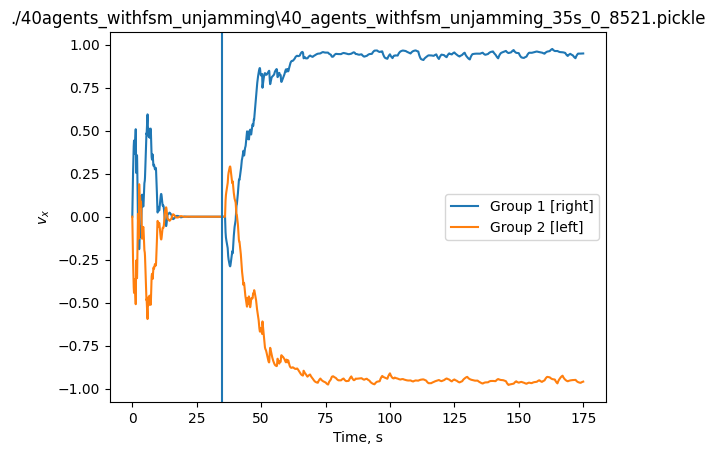

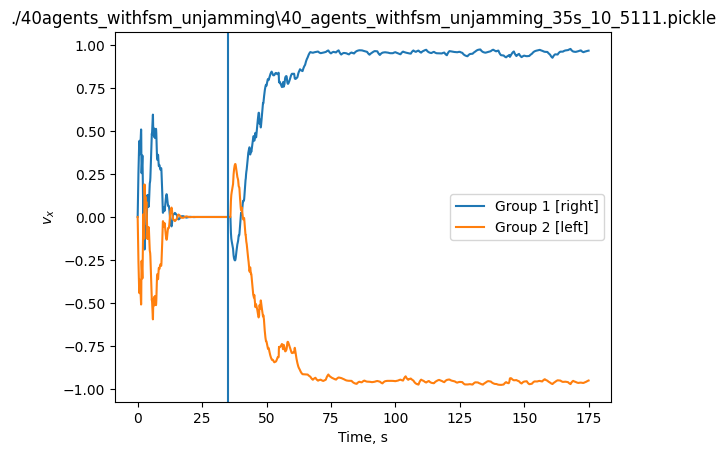

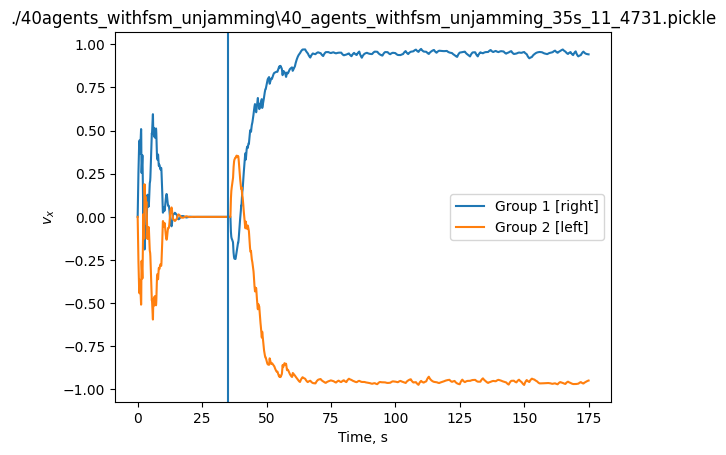

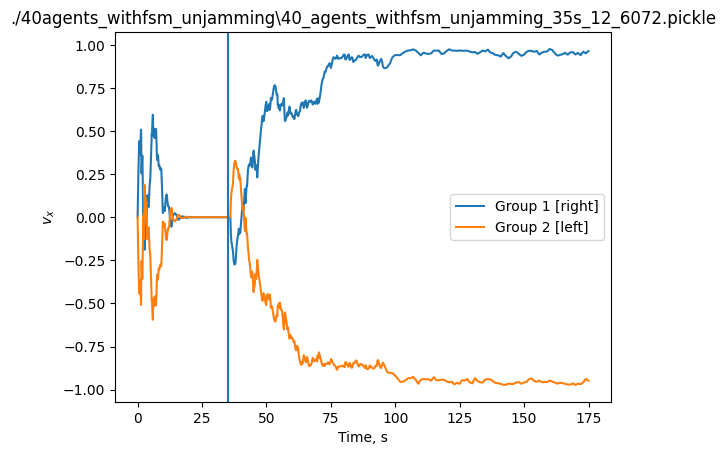

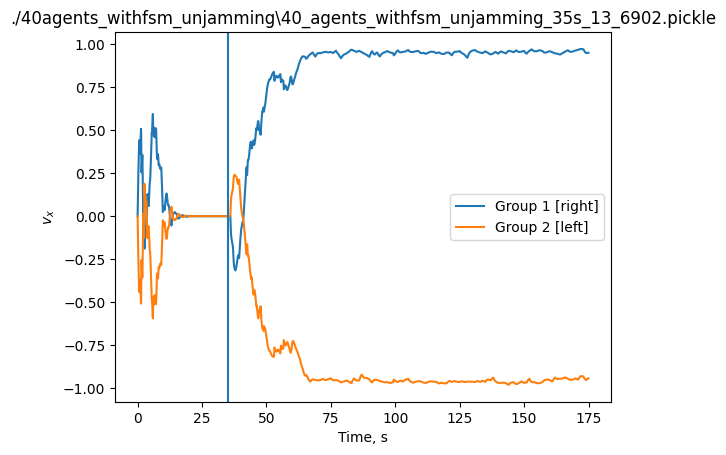

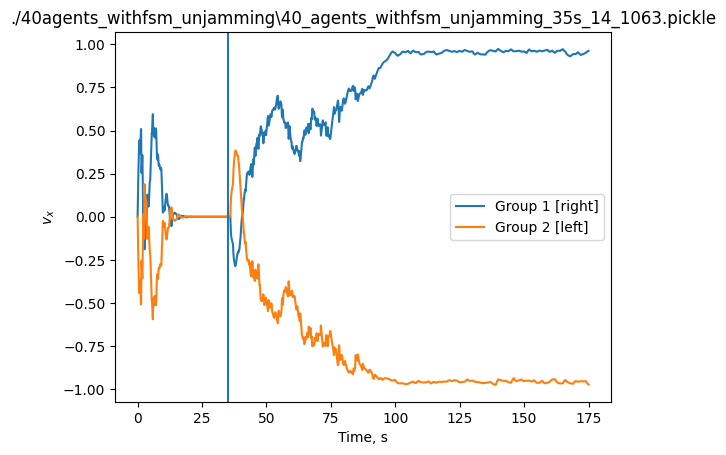

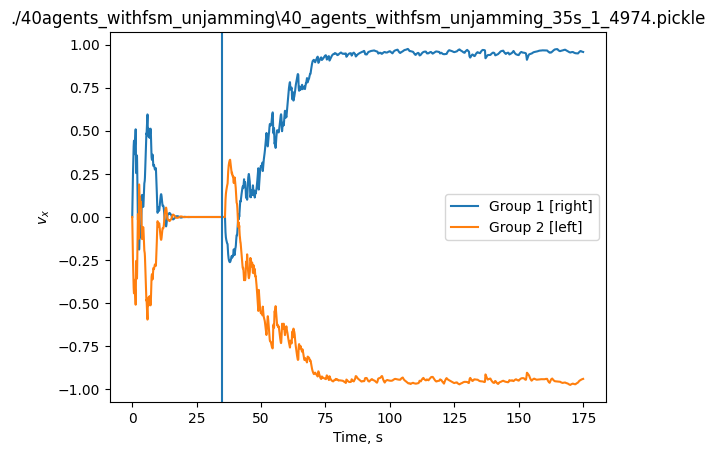

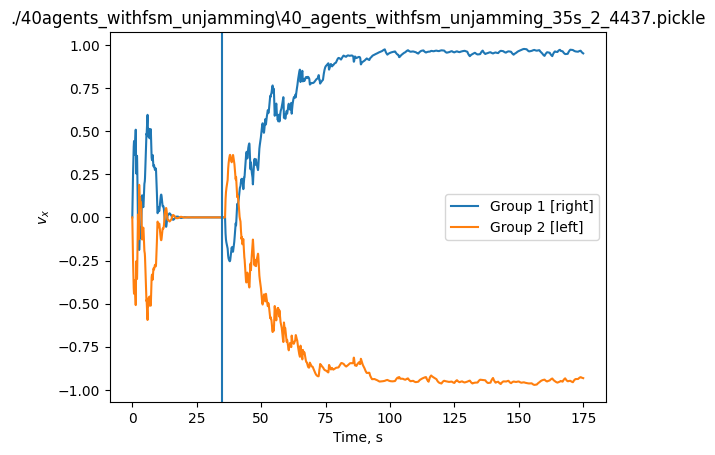

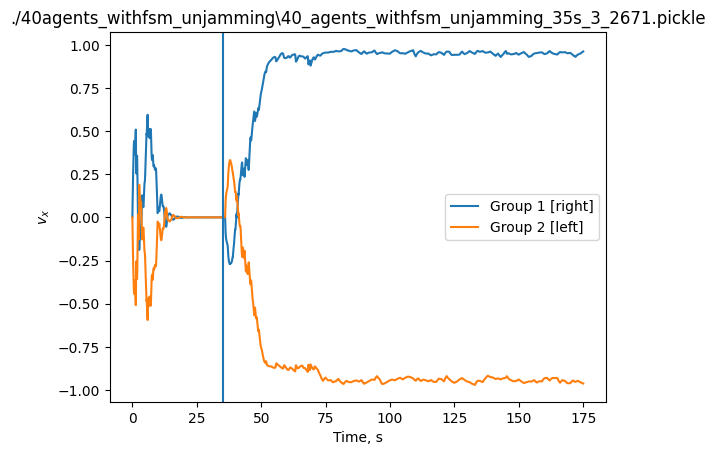

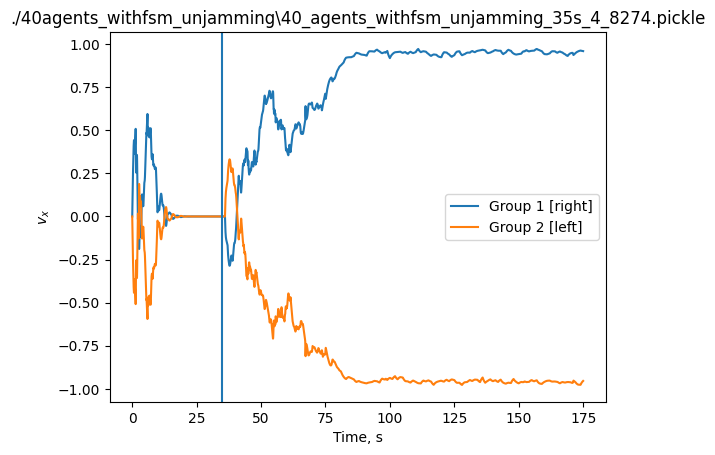

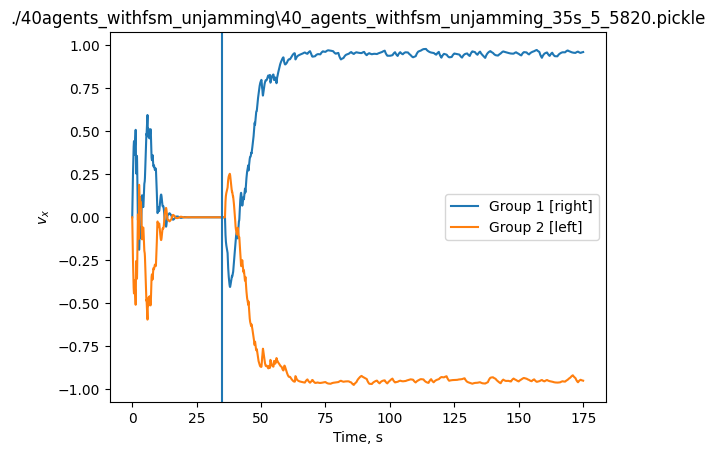

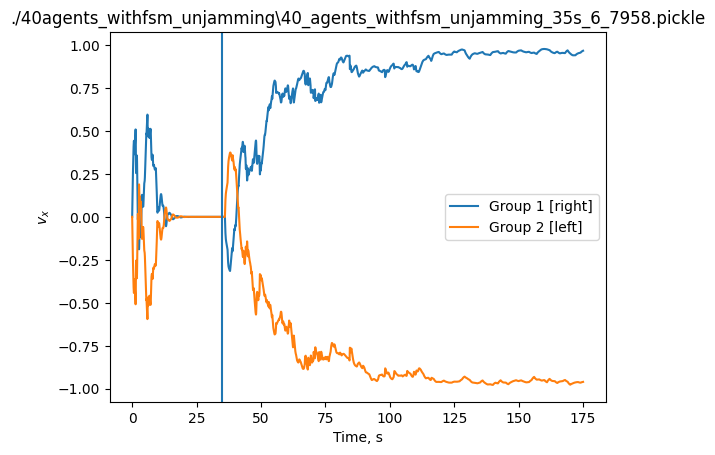

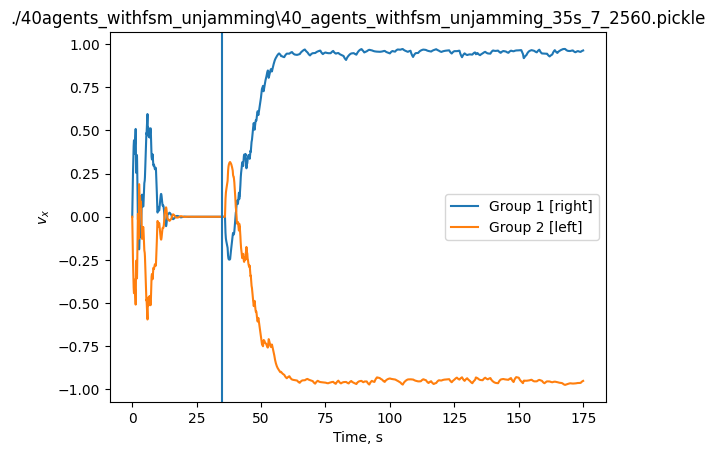

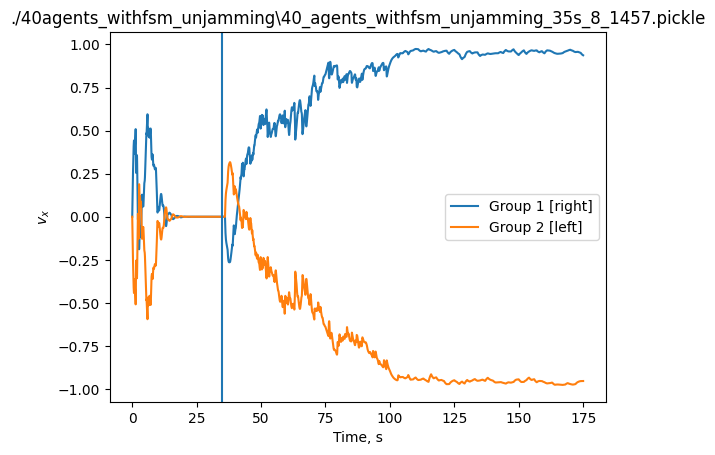

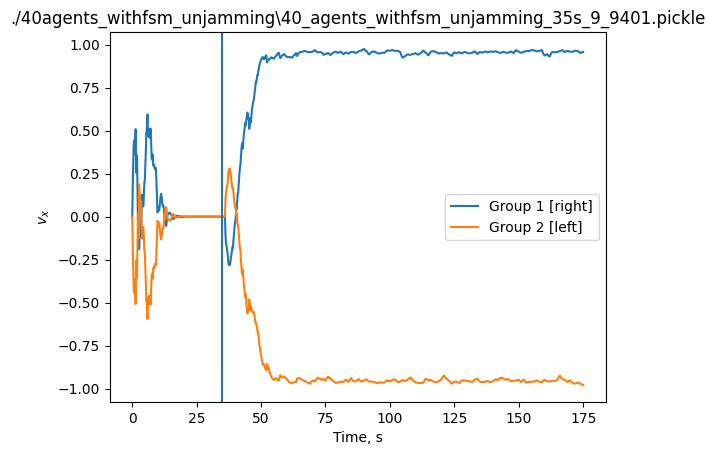

In [180]:

import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype']='none'
from glob import glob
filestart='./40agents_withfsm_unjamming/40*.pickle'
files=glob(filestart)
for file in files:
    with open(file,'rb') as f:
        alldata=pickle.load(f)
        uData=alldata['uData']
        g1=len(uData[0])//2
    plt.figure()
    print(file)
    
    uData_p = np.array(uData)
    # vData_p = np.array(vData)
    print(uData_p.shape)
    order_g1 = np.mean(uData_p[:, :g1], axis = 1)
    order_g2 = np.mean(uData_p[:, g1:], axis = 1)
    t = np.arange(0, totalTime, deltaT)
    
    
    plt.plot(t, order_g1[:-1], label = 'Group 1 [right]')
    plt.plot(t, order_g2[:-1], label = 'Group 2 [left]')
    # plt.xlim([0, 10])
    plt.title(file)
    # plt.title('Average x-component velocity')
    plt.xlabel('Time, s')
    plt.ylabel(r'$v_{x}$')
    # plt.xscale('log')
    plt.axvline(35)
    plt.legend()

In [57]:
with open('./jam_length/80_agents_withfsm_unjamming_35s_0_4731.pickle','rb') as file:
    alldata=pickle.load(file)

# alldata['xData'][0]

In [29]:

for i in range(timeStep):
    velocity=np.array([uData[i],vData[i]]).T

    angle=np.arctan2(velocity[:,1],velocity[:,0])
    delta_theta=np.arctan2(np.sin(desiredDirectionA-angle),np.cos(desiredDirectionA-angle))
    delta_theta.mean()

array([ 2. ,  4.5,  7. ,  9.5, 12. , 14.5, 17. , 19.5, 22. , 24.5, 27. ,
       29.5, 32. , 34.5, 37. , 39.5])

(0.0, 1.4)

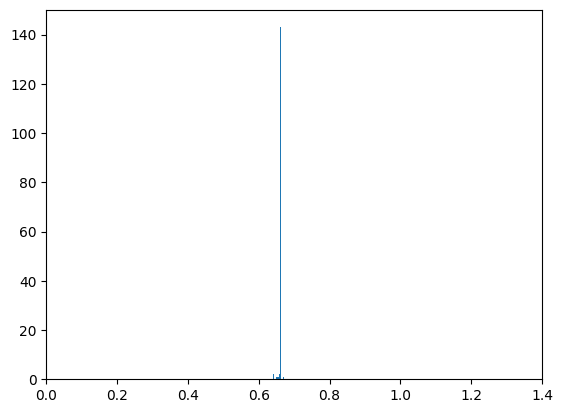

In [36]:
i=-100
desiredDirectionA=np.arctan2(desiredDirection[:,1],desiredDirection[:,0])
velocity=np.array([uData[i],vData[i]]).T

angle=np.arctan2(velocity[:,1],velocity[:,0])
delta_theta=np.arctan2(np.sin(desiredDirectionA-angle),np.cos(desiredDirectionA-angle))
dphi_dt=delta_theta/(2*delta_theta**6/(1+delta_theta**6)+0.5)
plt.hist(np.abs(dphi_dt))
plt.xlim(0,1.4)

In [143]:
desiredDirectionA=np.arctan2(desiredDirection[:,1],desiredDirection[:,0])
filename='./images/nematic_ajamresolve_test'
for i in range(0,timeStep,125):
# for i in (14*200,14*200+1):
    plt.figure()

    velocity=np.array([uData[i],vData[i]]).T
    
    angle=np.arctan2(velocity[:,1],velocity[:,0])
    delta_theta=np.arctan2(np.sin(desiredDirectionA-angle),np.cos(desiredDirectionA-angle))
    dphi_dt=delta_theta/(2*delta_theta**6/(1+delta_theta**6)+0.5)
    g1=len(angle)//2
    plt.hist(np.abs(angle[:g1]),density=True,alpha=0.5,color='red')
    plt.hist(np.abs(angle[g1:]),density=True,alpha=0.5,color='blue')
    plt.xlim(0,np.pi)
    
    # plt.xlim(-1,Lx+1)
    # plt.ylim(-1,Ly+1)
    # plt.axhline(0)
    # plt.axhline(Ly)
    # plt.gca().set_aspect(1)
    plt.savefig(filename+'_prop_'+str(i)+'.png',facecolor='white')
    plt.close()

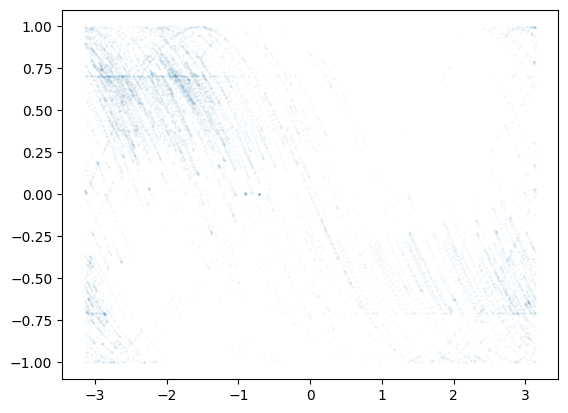

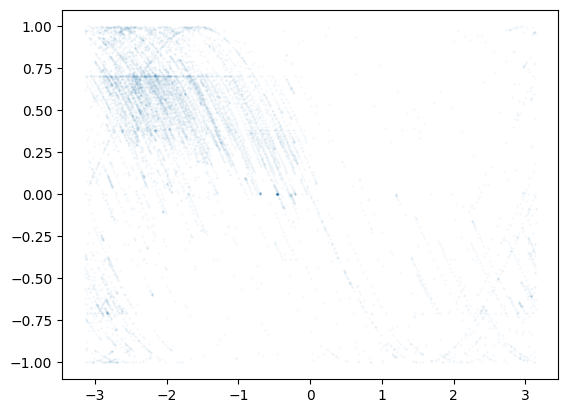

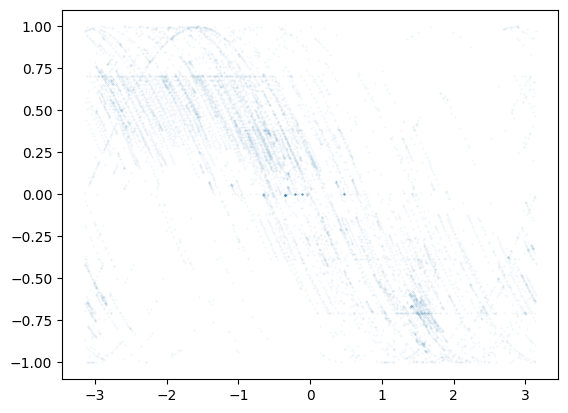

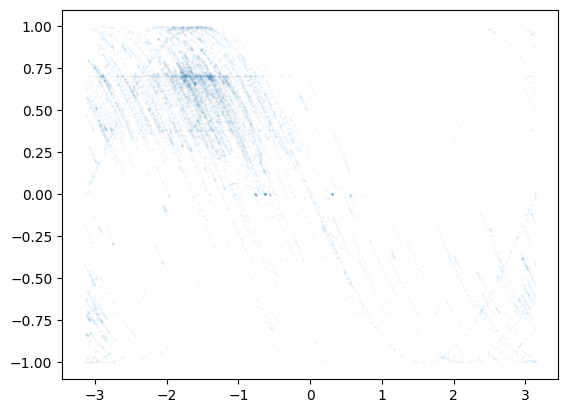

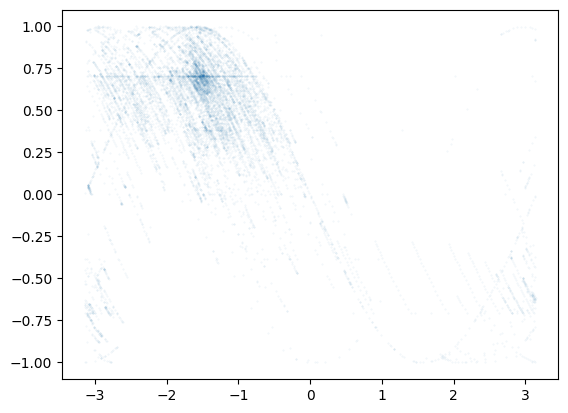

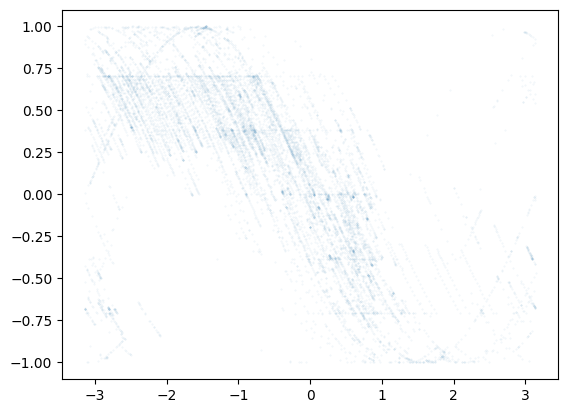

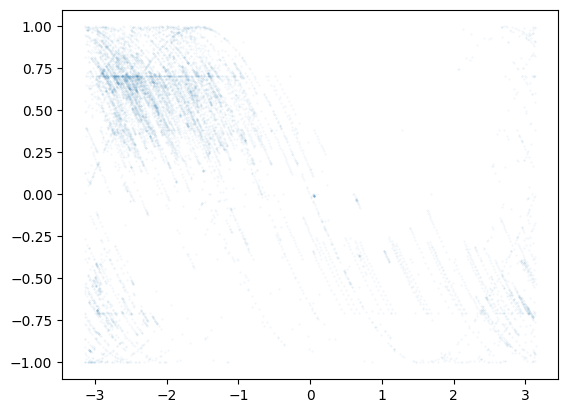

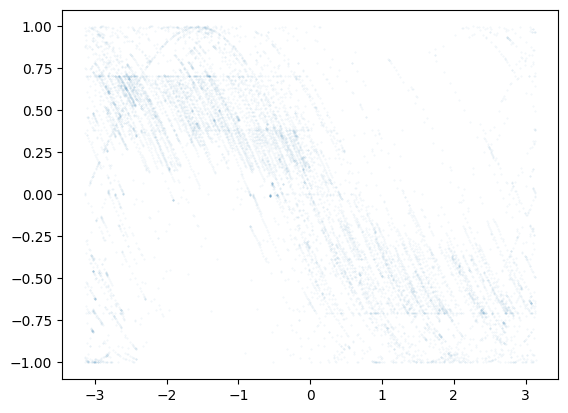

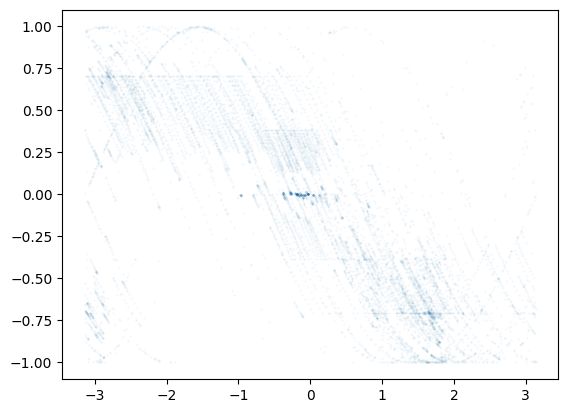

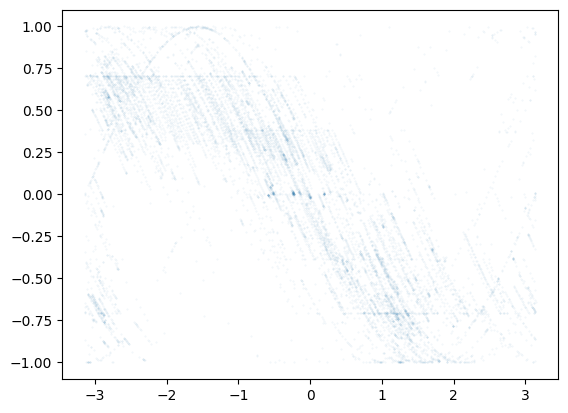

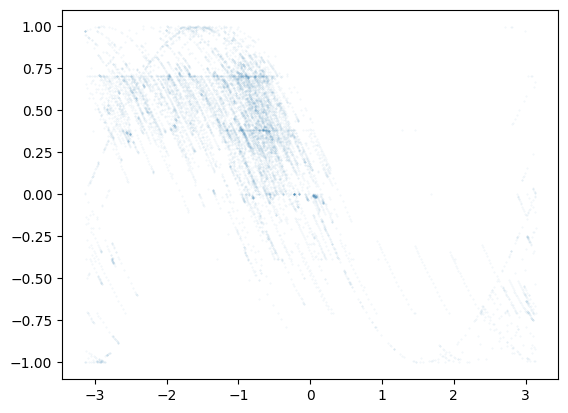

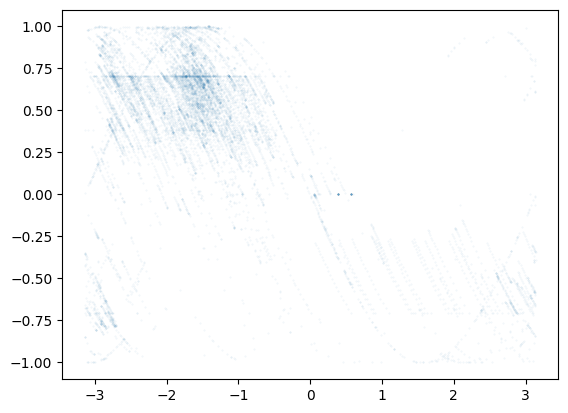

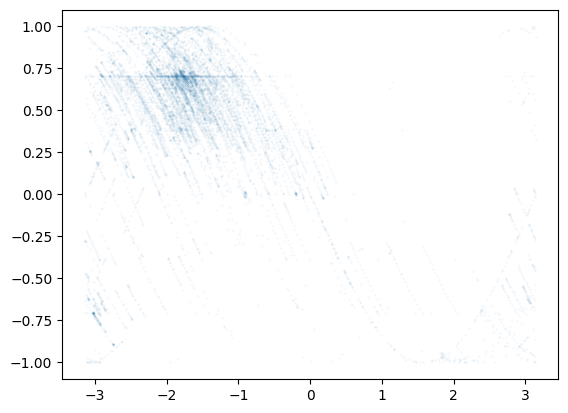

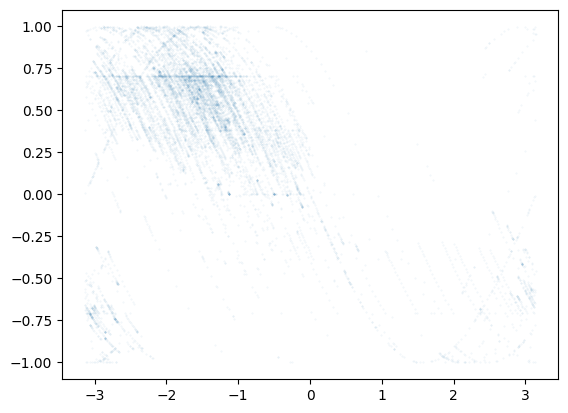

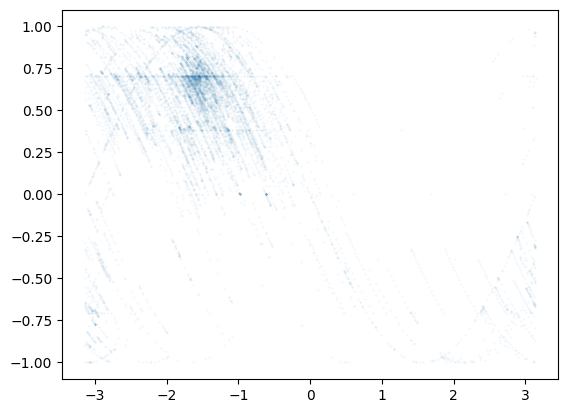

In [194]:
for filename in glob('./jam_length/150*.pickle'):
    plt.figure()
    with open(filename,'rb') as file:
        alldata=pickle.load(file)
    
    angles=[]
    rates=[]
    desangles=[]
    realrates=[]
    # filename='./images/jamresolve_test'
    for i in range(7000-1,12000,10):
    # for i in (14*200,14*200+1):
        # plt.figure()
        uvel=alldata['uData'][i]
        vvel=alldata['vData'][i]
        uvel_prev=alldata['uData'][i-10]
        vvel_prev=alldata['vData'][i-10]
        desdirs=alldata['desdirs'][i]
        desu=desdirs[:,0]
        desv=desdirs[:,1]
        dphi_dt=(uvel*(desv-vvel)-vvel*(desu-uvel))/(uvel**2+vvel**2)**0.5
        angle=np.arctan2(vvel,uvel)
        angle_prev=np.arctan2(vvel_prev,uvel_prev)
        realrate=np.arctan2(np.sin(angle-angle_prev),np.cos(angle-angle_prev))/(10*deltaT)
        angles.append(angle)
        # plt.hist(np.abs(dphi_dt),density=True)
        rates.append(dphi_dt)
        realrates.append(realrate)
        desangles.append(np.arctan2(desv,desu))
        # plt.xlim(0,1.4)
        
        # plt.xlim(-1,Lx+1)
        # plt.ylim(-1,Ly+1)
        # plt.axhline(0)
        # plt.axhline(Ly)
        # plt.gca().set_aspect(1)
        # plt.savefig(filename+'_prop_'+str(i)+'.png',facecolor='white')
        # plt.close()
    
    plt.scatter(np.array(angles).ravel(),np.array(rates).ravel(),s=0.1,alpha=0.1)
    # plt.ylim(-2,2)
    # delta_theta=np.linspace(-np.pi,np.pi,1000)
    # # dphi_dt=-(np.cos(delta_theta)*(np.sin(k)-np.sin(delta_theta))-np.sin(delta_theta)*(np.cos(k)-np.cos(delta_theta)))
    # dphi_dt2=delta_theta/(2*delta_theta**6/(1+delta_theta**6)+0.5)
    # plt.plot(delta_theta,dphi_dt2)

In [145]:
filename='./jam_length/150_agents_withfsm_unjamming_35s_2_9757.pickle'
# plt.figure()
with open(filename,'rb') as file:
    alldata=pickle.load(file)


filename='./images/jamresolve_test'
for i in range(7000,timeStep,125):
# for i in (14*200,14*200+1):
    plt.figure()
    uvel=alldata['uData'][i]
    vvel=alldata['vData'][i]
    desdirs=alldata['desdirs'][i]
    desu=desdirs[:,0]
    desv=desdirs[:,1]
    dphi_dt=(uvel*(desv-vvel)-vvel*(desu-uvel))/(uvel**2+vvel**2)**0.5
    angle=np.arctan2(vvel,uvel)
    g1=len(angle)//2
    plt.hist(np.abs(angle[:g1]),density=True,alpha=0.5,color='red')
    plt.hist(np.abs(angle[g1:]),density=True,alpha=0.5,color='blue')

    plt.xlim(0,np.pi)
    
    # plt.xlim(-1,Lx+1)
    # plt.ylim(-1,Ly+1)
    # plt.axhline(0)
    # plt.axhline(Ly)
    # plt.gca().set_aspect(1)
    plt.savefig(filename+'_prop_'+str(i)+'.png',facecolor='white')
    plt.close()



In [140]:
angle.shape

(150,)